# White-Box Explainability: Logistic Regression & Decision Trees

This notebook explores **white-box** explainability: models whose predictions can be
explained directly from their internal structure, with no separate explainer library
needed (contrast with the model-agnostic, black-box approach in
[LIME.ipynb](../LIME/LIME.ipynb)).

It uses the scikit-learn **Breast Cancer Wisconsin** dataset with two model families.

**Workflow:**
1. Load and split the data.
2. Train a `LogisticRegression` model and read global feature importance directly from
   its coefficients — first on raw features, then on standardized features.
3. Explain a single prediction locally as the sum of `coefficient x feature value` terms,
   and sanity-check that reconstruction against `predict_proba`.
4. Train a `DecisionTreeClassifier`, visualize its full structure, and trace the exact
   decision path taken for a single instance.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Say no to warnings!
warnings.filterwarnings('ignore')

SEED=2024

## 1. Load & Prepare the Data

Load the Breast Cancer Wisconsin dataset and split it into train/test sets. All features
are numeric, so no categorical encoding is needed.

In [2]:
# Dataset: Breast Cancer Wisconsin
data = load_breast_cancer()
X = data.data
y = data.target

# Data preprocessing
# The Breast Cancer Wisconsin dataset's features are numeric, we just need to split it
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=SEED)

## 2. Train a Linear Model: Logistic Regression

Fit a `LogisticRegression` model. Because it's linear, every prediction is a weighted sum
of the input features — the learned weights (coefficients) are themselves a global
explanation of what the model relies on.

In [3]:
# Training a linear model: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(xtrain, ytrain)

# Compute train and test accuracy
test_accuracy_lr = accuracy_score(ytest, lr_model.predict(xtest))
print(f"Test accuracy (Logistic Regression): {test_accuracy_lr}")

Test accuracy (Logistic Regression): 0.9298245614035088


### Feature Importance — Non-Standardized Coefficients

`mean area` (values in the hundreds) and `mean smoothness` (values around 0.1) sit on
very different scales, so comparing their raw coefficients directly is misleading — a
large coefficient may just be compensating for a small feature range, not signaling
higher importance.

Coefficients Logistic Regression:
mean radius: 2.224352028553145
worst radius: 1.2110832542746095
worst concavity: -1.0531675569365802
worst concave points: -1.0267786084629758
mean concavity: -0.7364261270216094
mean concave points: -0.5548327665164133
worst symmetry: -0.45584371677897007
worst smoothness: -0.45496187684259853
mean perimeter: -0.39734508573909744
worst texture: -0.30528340649740215


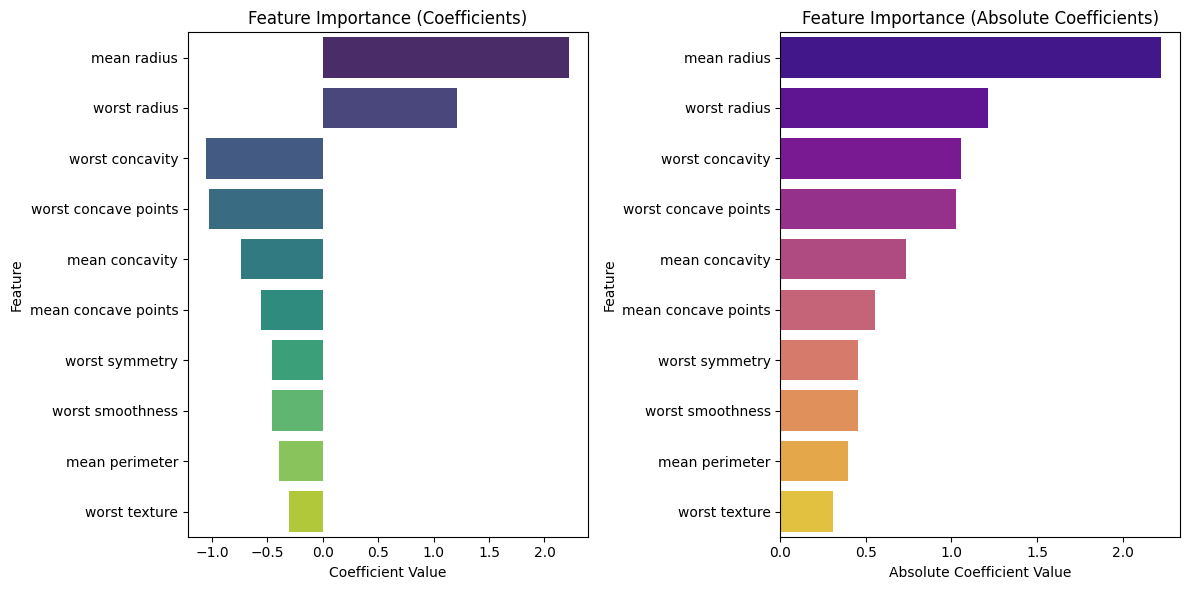

In [4]:
# Print the coefficients with variable names
print("Coefficients Logistic Regression:")
sorted_features = sorted(zip(data.feature_names, lr_model.coef_[0]), key=lambda x: abs(x[1]), reverse=True)[:10]
for feature, coef in sorted_features:
    print(f"{feature}: {coef}")

# Splitting feature names, coefficients e absolute values
features = [feature for feature, coef in sorted_features]
coefs = [coef for feature, coef in sorted_features]
abs_coefs = [abs(coef) for coef in coefs]

# Creating Bar Chart
plt.figure(figsize=(12, 6))

# Coefficients Chart
plt.subplot(1, 2, 1)
sns.barplot(x=coefs, y=features, palette="viridis")
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

# Absolute values Chart
plt.subplot(1, 2, 2)
sns.barplot(x=abs_coefs, y=features, palette="plasma")
plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Standardizing the Features

Refit the same `LogisticRegression` model, this time on standardized features (zero
mean, unit variance) via `StandardScaler`. Putting every feature on the same scale
makes the resulting coefficients directly comparable as an importance measure — unlike
the raw coefficients above, where magnitude conflates a feature's actual effect with
its arbitrary scale.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

# Say no to warnings!
warnings.filterwarnings('ignore')

SEED = 2024

data = load_breast_cancer()
X = data.data
y = data.target

# Standardizing features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Data preprocessing: train/test split
xtrain, xtest, ytrain, ytest = train_test_split(X_standardized, y, test_size=0.2, random_state=SEED)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(xtrain, ytrain)

test_accuracy_lr = accuracy_score(ytest, lr_model.predict(xtest))
print(f"Test accuracy (Logistic Regression): {test_accuracy_lr}")


Test accuracy (Logistic Regression): 0.9824561403508771


#### Feature Importance — Standardized Coefficients

Same plotting logic as before, but now the coefficient magnitudes are directly
comparable across features.

Logistic Regression coefficients:
worst texture: -1.329137762719905
radius error: -1.2635222364123393
worst radius: -1.0219855377878007
worst area: -0.9305496392715195
mean concave points: -0.9207012351774341
area error: -0.8578331586315614
worst concavity: -0.8536553952055836
mean concavity: -0.843523195708953
worst concave points: -0.838006514510313
worst symmetry: -0.777771146174695


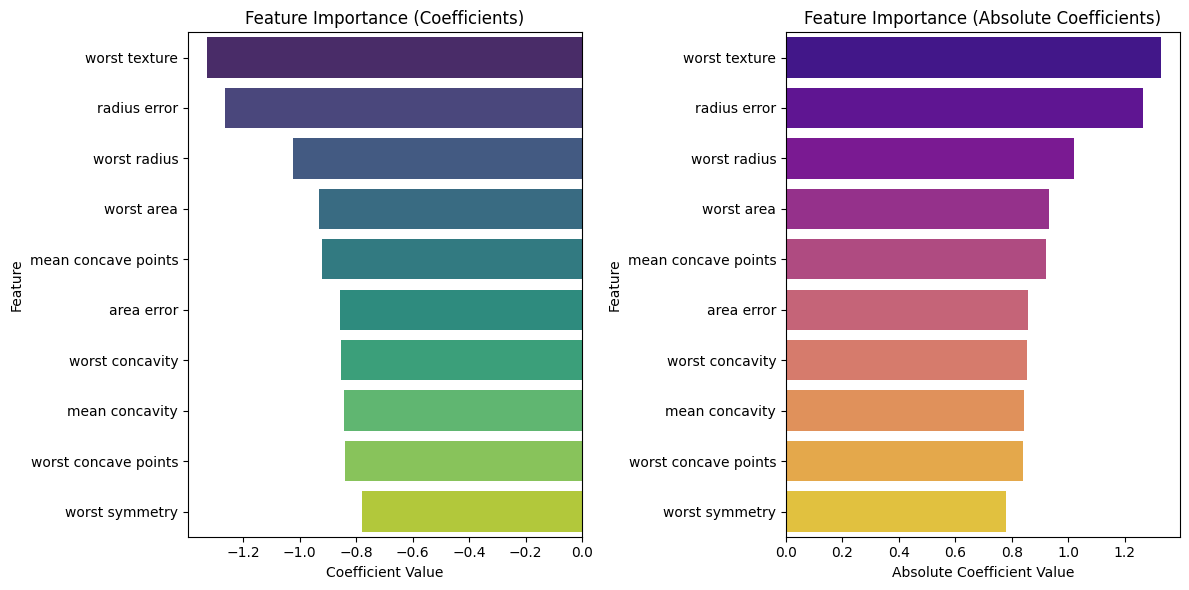

In [6]:
print("Logistic Regression coefficients:")
sorted_features = sorted(zip(data.feature_names, lr_model.coef_[0]), key=lambda x: abs(x[1]), reverse=True)[:10]
for feature, coef in sorted_features:
    print(f"{feature}: {coef}")

features = [feature for feature, coef in sorted_features]
coefs = [coef for feature, coef in sorted_features]
abs_coefs = [abs(coef) for coef in coefs]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=coefs, y=features, palette="viridis")
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.subplot(1, 2, 2)
sns.barplot(x=abs_coefs, y=features, palette="plasma")
plt.title("Feature Importance (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 3. Local Explanation for a Single Instance

For a linear model, an individual prediction decomposes exactly into
`intercept + sum(coefficient x feature value)` — no approximation or perturbation-based
explainer needed. `explain_lr_local` computes that per-feature breakdown for one test
instance.

Local explaination for instance 1 (true label: 0)
Intercept: 0.2015239113045528
mean radius: 1.1879485242391545 * -0.24093932060064252 = -0.2862235103387178
mean texture: 0.3002734542913885 * -0.44849386817733955 = -0.1346708030261164
mean perimeter: 1.1875532876625208 * -0.24440890684692174 = -0.2902486008600647
mean area: 1.1294241380988297 * -0.33308773216345144 = -0.37619732480999996
mean smoothness: 0.7429472026036915 * -0.01581055335253646 = -0.01174640638488338
mean compactness: 0.3877286170243026 * 0.3889800738419338 = 0.1508187060807441
mean concavity: 0.8550021219397657 * -0.843523195708953 = -0.721214122236567
mean concave points: 1.1759696857604847 * -0.9207012351774341 = -1.0827167422108972
mean symmetry: 0.17663764640972213 * 0.3081152660198795 = 0.05442475541265694
mean fractal dimension: -0.48022894570476987 * 0.24256433259125976 = -0.11648641370588182
radius error: 0.5043074947041366 * -1.2635222364123393 = -0.6372037335480747
texture error: -0.5340583440354487 * 0.375

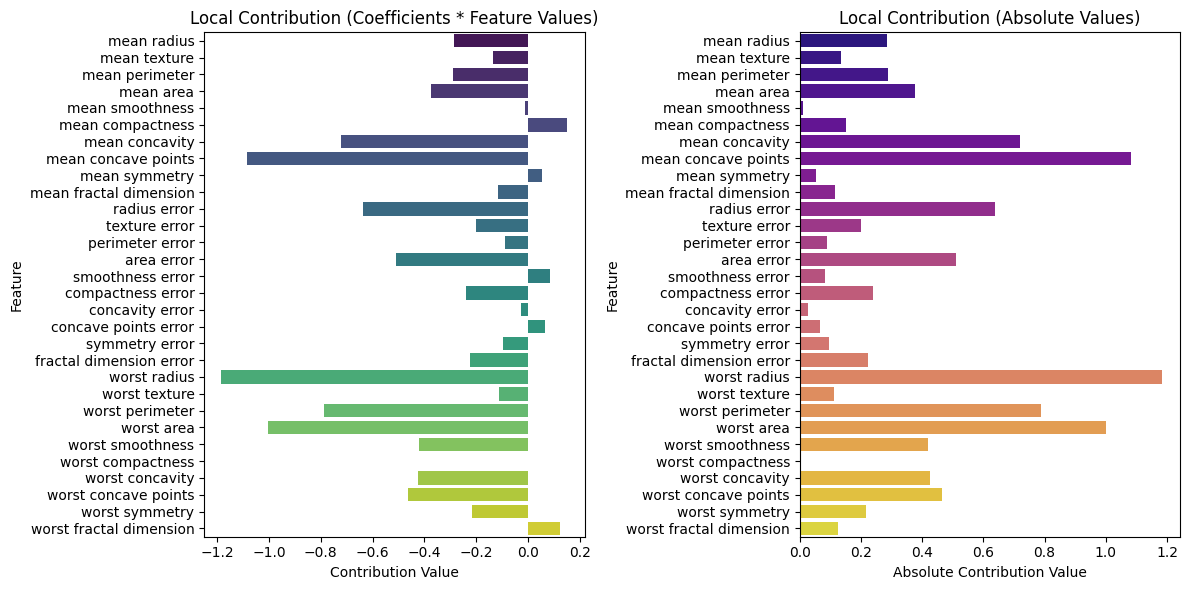

In [7]:
# Select an instance for local explaination
instance_index = 1  # e.g. second datapoint
instance = xtest[instance_index]
true_label = ytest[instance_index]

# Utility for local explainations on Logistic Regression
def explain_lr_local(model, instance, feature_names):
    contributions = []
    explanation = f"Intercept: {model.intercept_[0]}\n"
    for name, value, coef in zip(feature_names, instance, model.coef_[0]):
        contribution = value * coef
        contributions.append((name, value, coef, contribution))
        explanation += f"{name}: {value} * {coef} = {contribution}\n"
    return explanation, contributions

# Local explaination for Logistic Regression
print(f"Local explaination for instance {instance_index} (true label: {true_label})")
explanation, contributions = explain_lr_local(lr_model, instance, data.feature_names)
print(explanation)

# Prepare data for the Chart
features = [name for name, value, coef, contribution in contributions]
contrib_values = [contribution for name, value, coef, contribution in contributions]
abs_contrib_values = [abs(contribution) for contribution in contrib_values]

# Bar Char creation
plt.figure(figsize=(12, 6))

# Local contributes chart
plt.subplot(1, 2, 1)
sns.barplot(x=contrib_values, y=features, palette="viridis")
plt.title("Local Contribution (Coefficients * Feature Values)")
plt.xlabel("Contribution Value")
plt.ylabel("Feature")

# Local contributes' absolute values chart
plt.subplot(1, 2, 2)
sns.barplot(x=abs_contrib_values, y=features, palette="plasma")
plt.title("Local Contribution (Absolute Values)")
plt.xlabel("Absolute Contribution Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


### Sanity Check: Manual Sigmoid vs. `predict_proba`

Recompute the same instance's prediction by hand — weighted sum of features plus
intercept, passed through the sigmoid — and confirm it matches `lr_model.predict_proba`
exactly. This is what makes logistic regression white-box: the explanation *is* the
computation, not an approximation of it.

In [8]:
valori_datapoint = xtest[instance_index]
somma_pesata = np.dot(valori_datapoint,lr_model.coef_[0])+lr_model.intercept_[0]
post_logistica = 1 / (1 + np.exp(-somma_pesata))
vettore_risultato = [1-post_logistica,post_logistica]
print(vettore_risultato)
print(lr_model.predict_proba([valori_datapoint])[0])

[np.float64(0.9998735002330708), np.float64(0.000126499766929219)]
[9.99873500e-01 1.26499767e-04]


## 4. Train a Decision Tree

Switch to a `DecisionTreeClassifier`. Trees are white-box in a different way than linear
models: instead of additive feature weights, the explanation is the sequence of
threshold splits leading to a prediction.

In [9]:
# Training a Decision Tree
dt_model = DecisionTreeClassifier(random_state=SEED)
dt_model.fit(xtrain, ytrain)

test_accuracy_dt = accuracy_score(ytest, dt_model.predict(xtest))
print(f"Test accuracy (Decision Tree): {test_accuracy_dt}")

Test accuracy (Decision Tree): 0.956140350877193


### Visualize the Full Tree

`plot_tree` renders every split in the trained tree, giving a global view of the rules
the model learned.

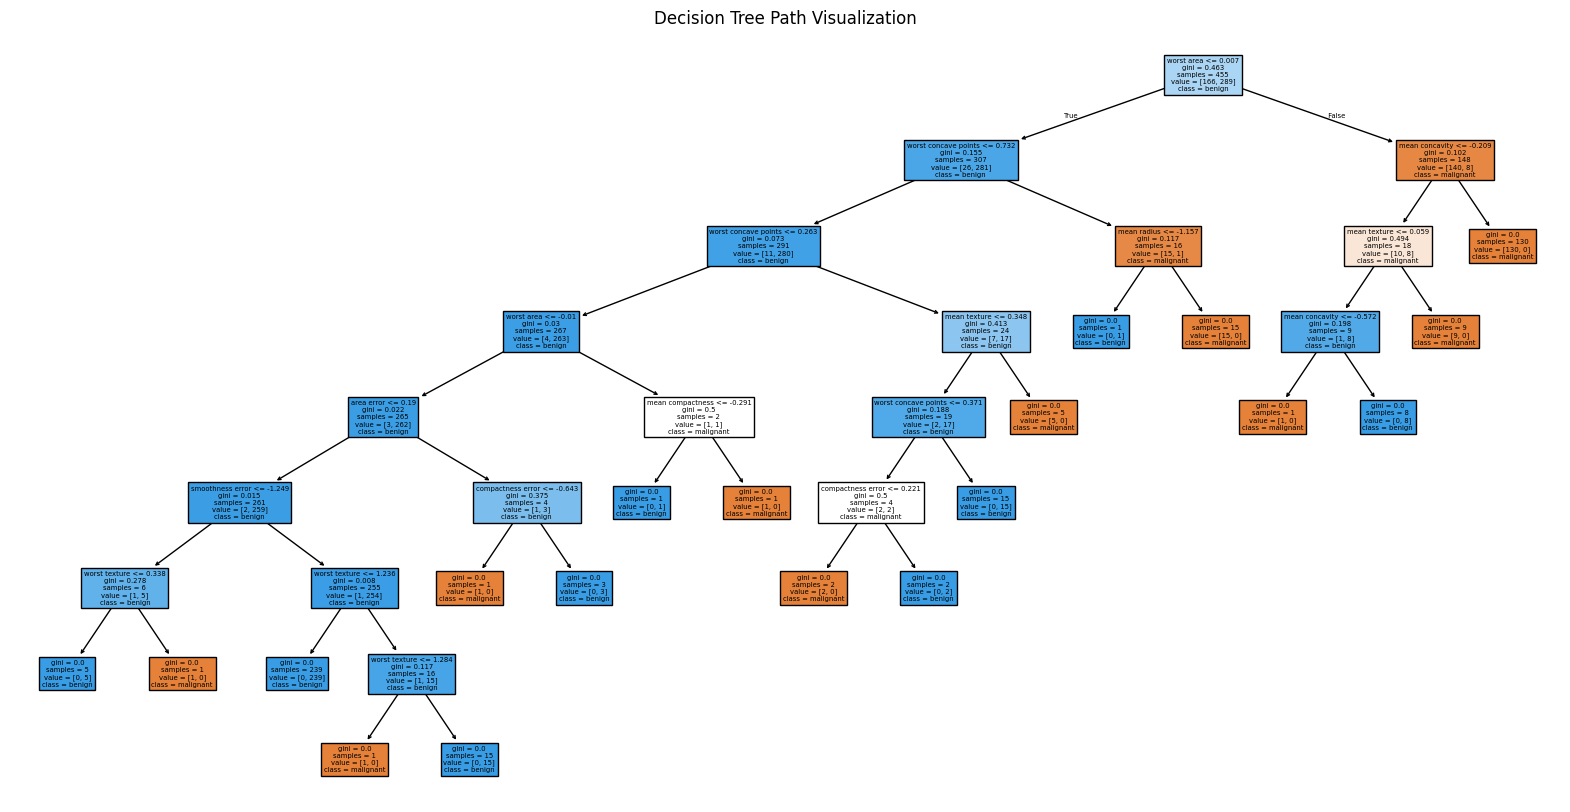

In [10]:
# Tree paths visualization
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.title("Decision Tree Path Visualization")
plt.show()

### Trace the Decision Path for a Single Instance

`plot_dt_path` walks the exact sequence of nodes `decision_path` visits for one instance
and prints the threshold test at each step — the tree equivalent of the coefficient
breakdown used for the Logistic Regression above.

In [11]:
# Tracking the local paths
def plot_dt_path(dt_model, instance, feature_names):
    node_indicator = dt_model.decision_path([instance])
    leaf_id = dt_model.apply([instance])

    node_index = node_indicator.indices[node_indicator.indptr[0]: node_indicator.indptr[1]]

    print(f"Tree path for the instance {instance_index} (true label: {true_label}):")
    for node_id in node_index:
        if leaf_id == node_id:
            print(f"-> leaf {node_id}, predicted label: {dt_model.classes_[dt_model.tree_.value[node_id].argmax()]}")
        else:
            if instance[dt_model.tree_.feature[node_id]] <= dt_model.tree_.threshold[node_id]:
                threshold_sign = "<="
            else:
                threshold_sign = ">"
            print(f"-> node {node_id}, {feature_names[dt_model.tree_.feature[node_id]]} {threshold_sign} {dt_model.tree_.threshold[node_id]}")


plot_dt_path(dt_model, instance, data.feature_names)


Tree path for the instance 1 (true label: 0):
-> node 0, worst area > 0.006973414201638661
-> node 30, mean concavity > -0.20915722846984863
-> leaf 36, predicted label: 0
